In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("huanghanchina/pascal-voc-2012")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/huanghanchina/pascal-voc-2012


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devdgohil/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset


In [3]:
import json
import os
import time
import torch

In [9]:
img_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images"
config_path = '/kaggle/working/config.json'
mask_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps"

In [10]:
print(len(os.listdir(img_path)))
print(len(os.listdir(mask_path)))

7393
14780


In [11]:
from torchvision import datasets, transforms as T
from torch.utils.data import DataLoader, Subset, random_split

def benchmark_num_workers(batch_size, img_size, num_workers_list=[0, 2, 4, 8]):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = T.Compose([
        T.Resize(img_size),
        T.ToTensor()
    ])

    dataset = datasets.FakeData(transform=transform)

    results = {}
    for nw in num_workers_list:
        loader = DataLoader(dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=nw,
                            pin_memory=(device == "cuda"))
        
        start = time.time()
        for i, batch in enumerate(loader):
            
            batch = batch[0].to(device, non_blocking=True)
            
            if i>50:
                break
        end = time.time()
        
        epoch_time = end - start
        results[nw] = epoch_time
        print(f"num_workers={nw} → epoch_time={epoch_time:.4f}s")

    best_nw = min(results, key=results.get)

    sorted_results = dict(sorted(results.items(),key=lambda kv: kv[1]))
    print(f"Benchmark: {sorted_results}")
    print(f"Selected: {best_nw}")

    return best_nw 

def load_config(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        config = json.load(f)

    return config

In [12]:
from dataclasses import dataclass

@dataclass
class Utils:

    CONFIG_PATH: str = "/kaggle/working/config.json"

    def __post_init__(self):

        self.CONFIG: dict = load_config(self.CONFIG_PATH)

In [23]:
import json

config = {}
def save_config(config, path):
    with open(path, 'w') as f:
        json.dump(config, f, indent=2)

save_config(config, config_path)

utils = Utils()
config = utils.CONFIG

# config.json values take priority — setdefault won't overwrite existing keys
# ── Paths ─────────────────────────────────────────────────────────────────
config.setdefault('images_dir',     img_path)
config.setdefault('mask_dir',       mask_path)
config.setdefault('checkpoint_dir', '/kaggle/working/checkpoints')
config.setdefault('best_model_dir', '/kaggle/working/best_model')

# ── Data ──────────────────────────────────────────────────────────────────
config.setdefault('img_size',       224)   # 224 = VGG native, no interpolation needed
config.setdefault('max_samples',    None)  # Oxford has ~7k — use all
config.setdefault('split_size',     0.85)
config.setdefault('cache_ram',      False)
config.setdefault('max_cache_size',      0)

# ── Model ─────────────────────────────────────────────────────────────────
config.setdefault('latent_channels', 256)

# ── Training ──────────────────────────────────────────────────────────────
config.setdefault('batch_size',      16)   # 224px is heavier than 128px — 16 safe on T4
config.setdefault('max_iterations',  60)
config.setdefault('lr',              2e-4)
config.setdefault('weight_decay',    1e-5)
config.setdefault('grad_clip',       1.0)
config.setdefault('accum_steps',     1)    # effective batch = 32
config.setdefault('patience',        8)
config.setdefault('min_delta',       1e-6)
config.setdefault('resume',          None)
config.setdefault('save_every',      10)

# ── Losses ────────────────────────────────────────────────────────────────
config.setdefault('lambda_l1',          1.0)
config.setdefault('lambda_perceptual',  0.1)
config.setdefault('num_workers',        4)

save_config(config, utils.CONFIG_PATH)

In [26]:
load_config(config_path)

{'images_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images',
 'mask_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps',
 'checkpoint_dir': '/kaggle/working/checkpoints',
 'best_model_dir': '/kaggle/working/best_model',
 'img_size': 224,
 'max_samples': None,
 'split_size': 0.85,
 'cache_ram': False,
 'max_cache_size': 0,
 'latent_channels': 256,
 'batch_size': 16,
 'max_iterations': 60,
 'lr': 0.0002,
 'weight_decay': 1e-05,
 'grad_clip': 1.0,
 'accum_steps': 1,
 'patience': 8,
 'min_delta': 1e-06,
 'resume': None,
 'save_every': 10,
 'lambda_l1': 1.0,
 'lambda_perceptual': 0.1,
 'num_workers': 4}

In [27]:
!nvidia-smi

Sun Mar  8 12:53:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
!python /kaggle/input/models/dibyenducontroversy/wfeaf/pytorch/default/1/jupyter_ddp_train_ae_simple.py

Rank 1 initializing on GPU Tesla T4
Rank 0 initializing on GPU Tesla T4
  [model] ResNetAE (with skips) | params: 18.32M
  [dirs] checkpoints → /kaggle/working/checkpoints
  [dirs] best model  → /kaggle/working/best_model
  [train] 6281 samples | [val] 1109 samples
  Starting training for 60 epochs

Corrupt JPEG data: premature end of data segment
Epoch   1/60 | LR: 0.000200 | Time: 235.2s
  Train | total=0.78120  l1=0.29919  perceptual=4.82012
  Val   | total=0.47860  l1=0.22853  perceptual=2.50071
----------------------------------------------------------------------
    [ckpt] saved → /kaggle/working/checkpoints/best_model.pth
    [best] weights        → /kaggle/working/best_model/best_weights.pth
    [best] optimizer state → /kaggle/working/best_model/best_optimizer_state.pth
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Epoch   2/60 | LR: 0.000200 | Time: 211.0s
  Train | total=0.40004  l1=0.18884  perceptual=2.11203
  

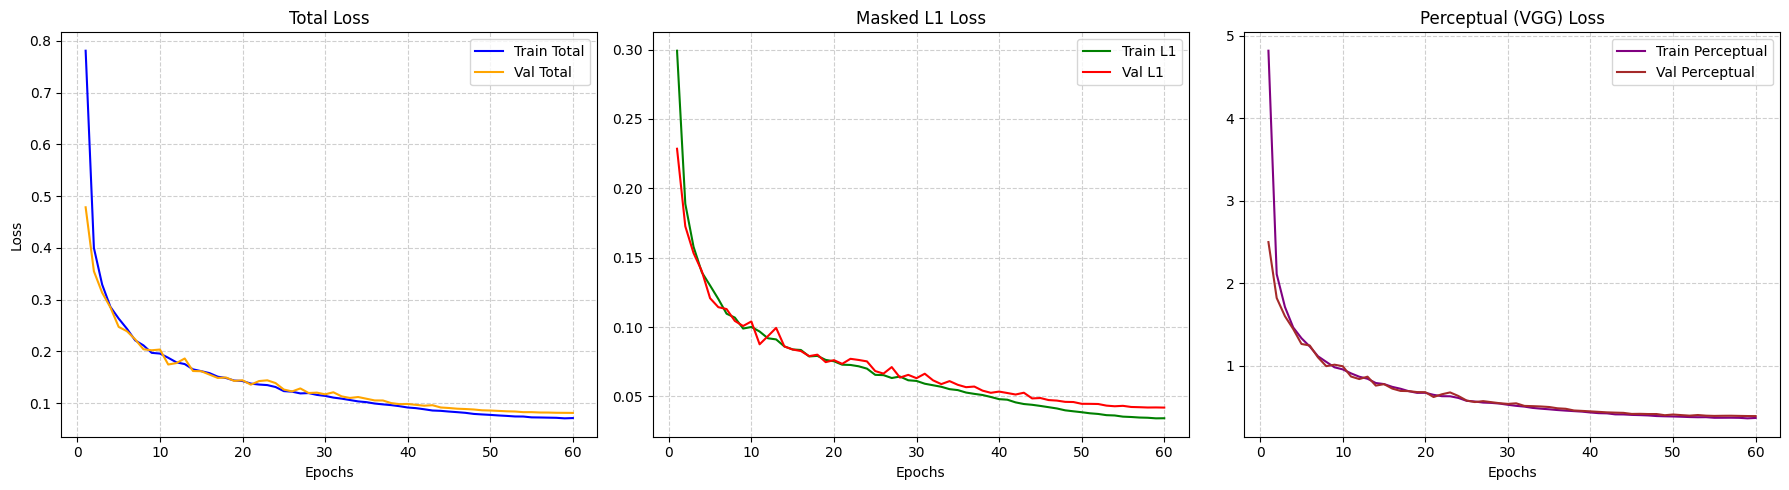

In [29]:
import json
import matplotlib.pyplot as plt

# Define the path where your script saved the history
history_path = '/kaggle/working/checkpoints/history.json'

# Load the data
with open(history_path, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_total']) + 1)

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Total Loss
axes[0].plot(epochs, history['train_total'], label='Train Total', color='blue')
axes[0].plot(epochs, history['val_total'], label='Val Total', color='orange')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot L1 Loss Breakdown
axes[1].plot(epochs, history['breakdown']['l1']['train'], label='Train L1', color='green')
axes[1].plot(epochs, history['breakdown']['l1']['val'], label='Val L1', color='red')
axes[1].set_title('Masked L1 Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot Perceptual Loss Breakdown
axes[2].plot(epochs, history['breakdown']['perceptual']['train'], label='Train Perceptual', color='purple')
axes[2].plot(epochs, history['breakdown']['perceptual']['val'], label='Val Perceptual', color='brown')
axes[2].set_title('Perceptual (VGG) Loss')
axes[2].set_xlabel('Epochs')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("loss_plots.png")
plt.show()

In [31]:
import sys

# Add the directory containing your script to sys.path
sys.path.append("/kaggle/input/models/dibyenducontroversy/wfeaf/pytorch/default/1")

# Now you can import your script as a module
import jupyter_ddp_train_ae_simple


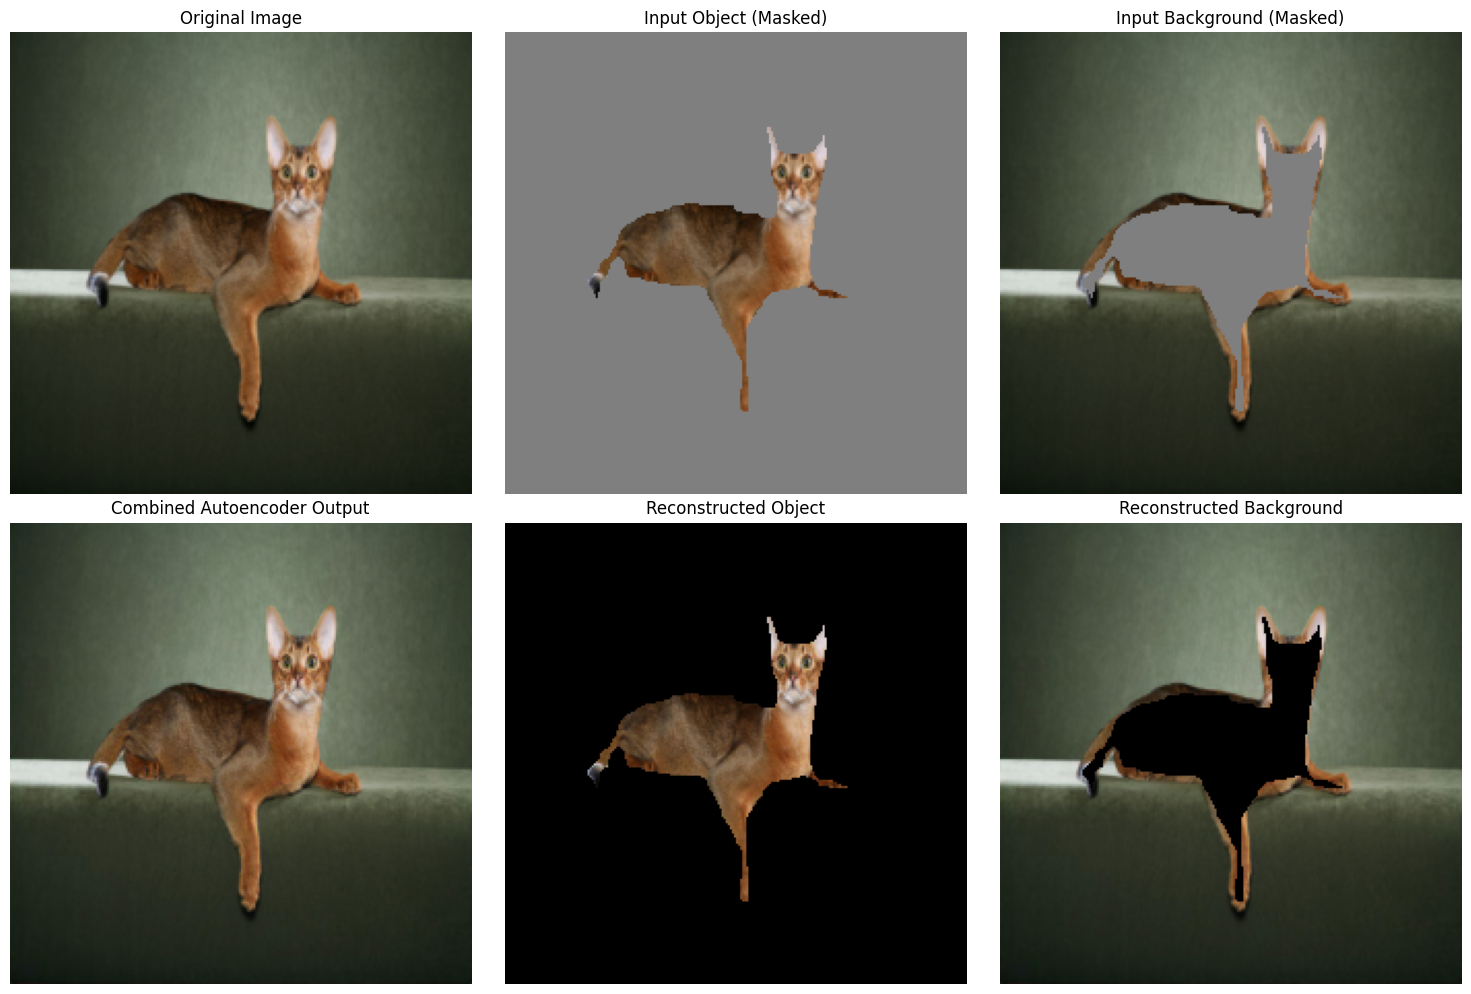

In [37]:
import torch
import torchvision.transforms.functional as TF
from torchvision.io import read_image

# --- Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model (using your Simple ResNetAE architecture)
# Assumes DualAutoencoder class is already in memory from your training cell
model = jupyter_ddp_train_ae_simple.DualAutoencoder(latent_channels=256).to(device)

# Load the weights
weights_path = '/kaggle/working/best_model/best_weights.pth'
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

# --- Data Loading ---
# Replace with a real validation image path
# --- Data Loading ---
img_path = '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/Abyssinian_1.jpg'
# Removed the '._' hidden file prefix
mask_path = '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps/Abyssinian_1.png'

# Image stays the same
img = read_image(img_path).float().div(255.0)

# Mask processing fixed for Trimaps
mask_raw = read_image(mask_path)
mask = (mask_raw == 1).float() # 1 = Foreground, 2 = Background, 3 = Outline

# Resize to match training
img = TF.resize(img, [224, 224])
mask = TF.resize(mask, [224, 224], interpolation=TF.InterpolationMode.NEAREST)

# Normalize exactly as SegmentTransform does: (x - 0.5) / 0.5
img_norm = TF.normalize(img, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

# Split into object and background inputs
obj_input = img_norm * mask
bg_input = img_norm * (1.0 - mask)

# Add batch dimension
obj_batch = obj_input.unsqueeze(0).to(device)
bg_batch = bg_input.unsqueeze(0).to(device)

# --- Inference ---
with torch.inference_mode():
    rec_obj, rec_bg, z_obj, z_bg = model(obj_batch, bg_batch)

# --- Post-Processing ---
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Remove batch dim, move to CPU, and reverse normalization
rec_obj_img = denormalize(rec_obj.squeeze(0).cpu())
rec_bg_img = denormalize(rec_bg.squeeze(0).cpu())
original_img = denormalize(img_norm).cpu()

# Apply the mask to the outputs to clean up unpenalized background static
mask_cpu = mask.cpu()
rec_obj_clean = rec_obj_img * mask_cpu
rec_bg_clean = rec_bg_img * (1.0 - mask_cpu)
combined_rec = rec_obj_clean + rec_bg_clean

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def to_plot(t):
    return t.permute(1, 2, 0).numpy()

axes[0, 0].imshow(to_plot(original_img))
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(to_plot(denormalize(obj_input.cpu())))
axes[0, 1].set_title("Input Object (Masked)")
axes[0, 1].axis('off')

axes[0, 2].imshow(to_plot(denormalize(bg_input.cpu())))
axes[0, 2].set_title("Input Background (Masked)")
axes[0, 2].axis('off')

axes[1, 0].imshow(to_plot(combined_rec))
axes[1, 0].set_title("Combined Autoencoder Output")
axes[1, 0].axis('off')

axes[1, 1].imshow(to_plot(rec_obj_clean))
axes[1, 1].set_title("Reconstructed Object")
axes[1, 1].axis('off')

axes[1, 2].imshow(to_plot(rec_bg_clean))
axes[1, 2].set_title("Reconstructed Background")
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('output.png')
plt.show()

In [ ]:
import json
import os

config_path = "/kaggle/working/config.json"
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        conf = json.load(f)
    print("Checkpoint Dir:", conf.get('checkpoint_dir', 'Not specified in JSON'))
else:
    print("config.json not found, using script defaults.")

In [30]:
os.listdir("/kaggle/working/checkpoints")

['epoch_045.pth',
 'epoch_020.pth',
 'epoch_050.pth',
 'history.json',
 'epoch_025.pth',
 'epoch_010.pth',
 'final_checkpoint.pth',
 'epoch_035.pth',
 'epoch_005.pth',
 'epoch_040.pth',
 'epoch_015.pth',
 'best_model.pth',
 'epoch_030.pth']

In [31]:
os.listdir('/kaggle/working')

['loss_plots.png',
 '.ipynb_checkpoints',
 'checkpoints',
 'best_model',
 'output.png',
 '.virtual_documents',
 'config.json']

In [37]:
import os
import shutil

img_paths = [
    os.path.join('/kaggle/working', 'loss_plots.png'),
    os.path.join('/kaggle/working', 'output.png')
]

dest = '/kaggle/working/best_model'

# Ensure the destination directory exists
os.makedirs(dest, exist_ok=True)

# 1. Move loss_plots.png (Index 0)
if os.path.exists(img_paths[0]):
    shutil.move(img_paths[0], os.path.join(dest, 'loss_plots.png'))
    print("✅ Moved loss_plots.png")
else:
    print("❌ Could not find loss_plots.png")

# 2. Move output.png (Index 1!)
if os.path.exists(img_paths[1]):
    shutil.move(img_paths[1], os.path.join(dest, 'output.png'))
    print("✅ Moved output.png")
else:
    print("❌ Could not find output.png")

✅ Moved loss_plots.png
❌ Could not find output.png


In [39]:
import os
import shutil

src_dir = '/kaggle/working/checkpoints'
dest_dir = '/kaggle/working/best_model'

# Ensure destination exists (it should, since your plots are there)
os.makedirs(dest_dir, exist_ok=True)

if os.path.exists(src_dir):
    print(f"Copying contents from {src_dir} to {dest_dir}...\n")
    
    # Loop through every file in the checkpoints folder
    for item in os.listdir(src_dir):
        s = os.path.join(src_dir, item)
        d = os.path.join(dest_dir, item)
        
        if os.path.isfile(s):
            shutil.copy2(s, d) # copy2 preserves file metadata like creation time
            print(f"✅ Copied: {item}")
        elif os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
            print(f"✅ Copied directory: {item}")
            
    print("\n🎉 All contents successfully copied!")
else:
    print(f"❌ Could not find {src_dir}. Are you sure it hasn't been moved already?")

# Verify the final contents of best_model
print("\nFinal contents of best_model:")
if os.path.exists(dest_dir):
    for item in sorted(os.listdir(dest_dir)):
        print(f" - {item}")

Copying contents from /kaggle/working/checkpoints to /kaggle/working/best_model...

✅ Copied: best_model.pth
✅ Copied: epoch_010.pth
✅ Copied: epoch_050.pth
✅ Copied: history.json
✅ Copied: epoch_040.pth
✅ Copied: epoch_030.pth
✅ Copied: epoch_060.pth
✅ Copied: epoch_020.pth
✅ Copied: final_checkpoint.pth

🎉 All contents successfully copied!

Final contents of best_model:
 - best_model.pth
 - best_optimizer_state.pth
 - best_weights.pth
 - epoch_010.pth
 - epoch_020.pth
 - epoch_030.pth
 - epoch_040.pth
 - epoch_050.pth
 - epoch_060.pth
 - final_checkpoint.pth
 - history.json


In [40]:
import os
import shutil

src_dir = '/kaggle/working/checkpoints'
# We will create a zip file named 'model_checkpoints.zip' in the working directory
zip_dest = '/kaggle/working/model_checkpoints' 

if os.path.exists(src_dir):
    print(f"Zipping contents of {src_dir}...\n")
    
    # shutil.make_archive creates a zip file. 
    # It automatically appends '.zip' to the destination name provided.
    shutil.make_archive(zip_dest, 'zip', src_dir)
    
    print(f"🎉 Successfully created {zip_dest}.zip!")
else:
    print(f"❌ Could not find {src_dir}. Are you sure it hasn't been moved already?")

# Verify the zip file was created
print("\nFinal contents of /kaggle/working/:")
for item in sorted(os.listdir('/kaggle/working/')):
    if item.endswith('.zip'):
        print(f" 📦 {item} (Ready for download!)")

Zipping contents of /kaggle/working/checkpoints...

🎉 Successfully created /kaggle/working/model_checkpoints.zip!

Final contents of /kaggle/working/:
 📦 model_checkpoints.zip (Ready for download!)


In [41]:
!ls -lh /kaggle/working/model_checkpoints.zip

-rw-r--r-- 1 root root 1.6G Mar  8 16:36 /kaggle/working/model_checkpoints.zip
